# Complete ML Pipeline: Neurodegenerative Disease Classification
## Professional End-to-End Machine Learning Project

**Author:** Data Science Team  
**Date:** December 2025  
**Objective:** Build a robust multiclass classification model for neurodegenerative disease prediction

---

### Pipeline Steps:
1. Problem Definition
2. Data Collection
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Cleaning
5. Feature Selection & Engineering
6. Split the Dataset
7. Model Selection
8. Model Training
9. Model Evaluation
10. Hyperparameter Tuning
11. Model Testing & Validation

## Step 1: Problem Definition

**Problem Statement:**  
Develop a machine learning model to classify neurodegenerative diseases based on clinical and neurological features.

**Target Diseases:**
- Alzheimer's Disease
- Parkinson's Disease
- Frontotemporal Dementia (FTD)
- Lewy Body Dementia (LBD)
- Vascular Dementia
- Mild Cognitive Impairment (MCI)

**Success Metrics:**
- Accuracy > 90%
- Balanced precision and recall across all classes
- F1-Score > 0.85

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
import os

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All libraries imported successfully!")
print(f"Python version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ All libraries imported successfully!
Python version: 2.3.3
NumPy version: 2.4.0


## Step 2: Data Collection

In [ ]:
# Load the dataset
df = pd.read_csv('dataset.csv')

print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]:,}")
print(f"Number of Features: {df.shape[1] - 1}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
df.head()

DATASET LOADED SUCCESSFULLY

Dataset Shape: (4889, 51)
Number of Samples: 4,889
Number of Features: 50

Memory Usage: 2.16 MB


,memory_loss_score,cognitive_decline_rate,motor_symptom_severity,visual_hallucination_freq,age,frontal_lobe_volume,temporal_lobe_volume,parietal_lobe_volume,occipital_lobe_volume,cerebellum_volume,...,cortical_thickness,neuronal_activity_rate,immune_inflammation_score,protein_aggregation_level,neuro_transmitter_level,brain_iron_concentration,neuroinflammation_index,oxidative_stress_score,vascular_health_index,disease
0,0.904583,0.849140,0.234753,0.090657,68.276868,0.802035,0.978392,0.443114,1.000000,0.648814,...,0.762323,1.000000,0.954175,0.972798,0.817780,0.813949,0.902941,1.000000,1.000000,Alzheimers
1,0.635970,0.777429,0.324385,0.029966,77.798156,0.691141,0.534134,0.747090,0.929306,0.759240,...,1.000000,0.560486,1.000000,0.567999,1.000000,0.178749,0.630662,0.651516,0.989857,Alzheimers
2,0.557201,0.486993,0.437158,0.530939,79.169915,0.554866,0.105733,0.839086,0.406945,0.753909,...,0.187106,0.468328,0.520450,0.432702,0.269761,0.571085,0.211524,0.453086,0.577391,LBD
3,0.662736,0.632723,0.315220,0.066781,73.587312,0.712125,0.311000,0.759167,0.670383,0.455423,...,0.980761,0.518244,1.000000,0.758681,0.337526,0.843456,0.790598,0.653716,0.748773,Vascular
4,0.618722,0.093352,0.122700,0.080953,69.501693,0.102574,0.553131,0.248206,0.823229,0.000000,...,0.102296,0.707348,0.032414,0.540834,0.218941,0.535622,0.073802,0.640177,0.108602,MCI


In [3]:
# Basic dataset information
print("\nDataset Info:")
print("="*70)
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4889 entries, 0 to 4888
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   memory_loss_score             4889 non-null   float64
 1   cognitive_decline_rate        4889 non-null   float64
 2   motor_symptom_severity        4889 non-null   float64
 3   visual_hallucination_freq     4889 non-null   float64
 4   age                           4889 non-null   float64
 5   frontal_lobe_volume           4889 non-null   float64
 6   temporal_lobe_volume          4889 non-null   float64
 7   parietal_lobe_volume          4889 non-null   float64
 8   occipital_lobe_volume         4889 non-null   float64
 9   cerebellum_volume             4889 non-null   float64
 10  brainstem_integrity           4889 non-null   float64
 11  hippocampus_volume            4889 non-null   float64
 12  amygdala_volume               4889 non-null   f

## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Target Variable Analysis

In [4]:
# Target variable distribution
print("\n" + "="*70)
print("TARGET VARIABLE ANALYSIS")
print("="*70)

disease_counts = df['disease'].value_counts()
disease_pct = df['disease'].value_counts(normalize=True) * 100

print("\nDisease Distribution:")
for disease, count in disease_counts.items():
    pct = disease_pct[disease]
    print(f"  {disease:15s}: {count:4d} samples ({pct:5.2f}%)")

# Check for class imbalance
max_count = disease_counts.max()
min_count = disease_counts.min()
imbalance_ratio = max_count / min_count

print(f"\nClass Balance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio < 1.5:
    print("✓ Dataset is well balanced")
elif imbalance_ratio < 3:
    print("⚠ Moderate class imbalance")
else:
    print("❌ Significant class imbalance - consider SMOTE or class weights")


TARGET VARIABLE ANALYSIS

Disease Distribution:
  Parkinsons     :  841 samples (17.20%)
  FTD            :  831 samples (17.00%)
  LBD            :  829 samples (16.96%)
  Vascular       :  806 samples (16.49%)
  Alzheimers     :  801 samples (16.38%)
  MCI            :  781 samples (15.97%)

Class Balance Ratio: 1.08:1
✓ Dataset is well balanced


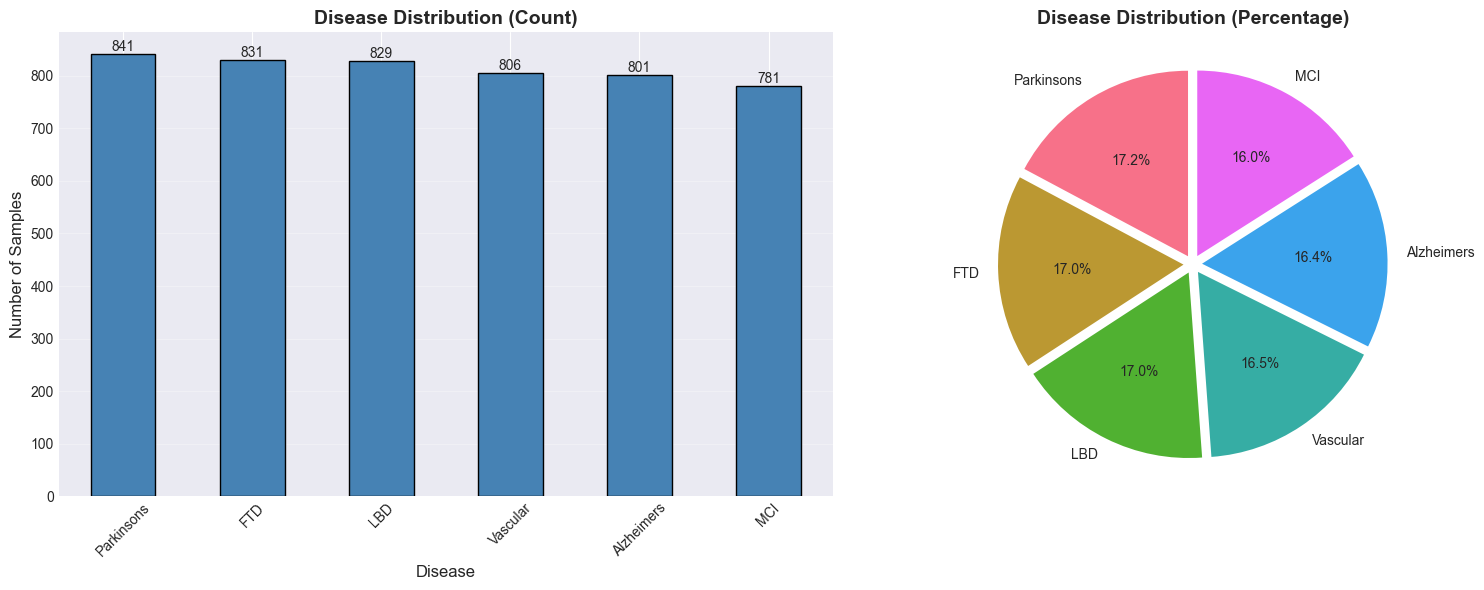

In [5]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
disease_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Disease Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disease', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart
colors = sns.color_palette('husl', len(disease_counts))
axes[1].pie(disease_counts, labels=disease_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors, explode=[0.05]*len(disease_counts))
axes[1].set_title('Disease Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 Missing Values Analysis

In [6]:
# Check for missing values
print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100

if missing_values.sum() == 0:
    print("\n✓ No missing values found in the dataset!")
else:
    missing_df = pd.DataFrame({
        'Column': missing_values.index,
        'Missing Count': missing_values.values,
        'Percentage': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    print("\nColumns with Missing Values:")
    print(missing_df.to_string(index=False))


MISSING VALUES ANALYSIS

✓ No missing values found in the dataset!


### 3.3 Statistical Summary

In [7]:
# Statistical summary of numerical features
print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumber of Numeric Features: {len(numeric_features)}")

# Display summary statistics
df[numeric_features].describe().T


STATISTICAL SUMMARY

Number of Numeric Features: 50


,count,mean,std,min,25%,50%,75%,max
memory_loss_score,4889.0,0.517044,0.208007,0.0,0.367374,0.521222,0.667704,1.0
cognitive_decline_rate,4889.0,0.597778,0.210042,0.0,0.449435,0.624737,0.756820,1.0
motor_symptom_severity,4889.0,0.455848,0.307890,0.0,0.181951,0.395706,0.744522,1.0
visual_hallucination_freq,4889.0,0.245775,0.267760,0.0,0.072480,0.135716,0.270493,1.0
age,4889.0,68.333385,10.215325,40.0,61.370685,68.536258,75.456468,95.0
frontal_lobe_volume,4889.0,0.586876,0.274305,0.0,0.394121,0.606653,0.799425,1.0
temporal_lobe_volume,4889.0,0.516124,0.277984,0.0,0.310229,0.515479,0.725379,1.0
parietal_lobe_volume,4889.0,0.588414,0.256055,0.0,0.403023,0.598569,0.783511,1.0
occipital_lobe_volume,4889.0,0.511961,0.265676,0.0,0.322151,0.519092,0.706620,1.0
cerebellum_volume,4889.0,0.592510,0.263028,0.0,0.415848,0.614154,0.792082,1.0


### 3.4 Feature Distribution Analysis

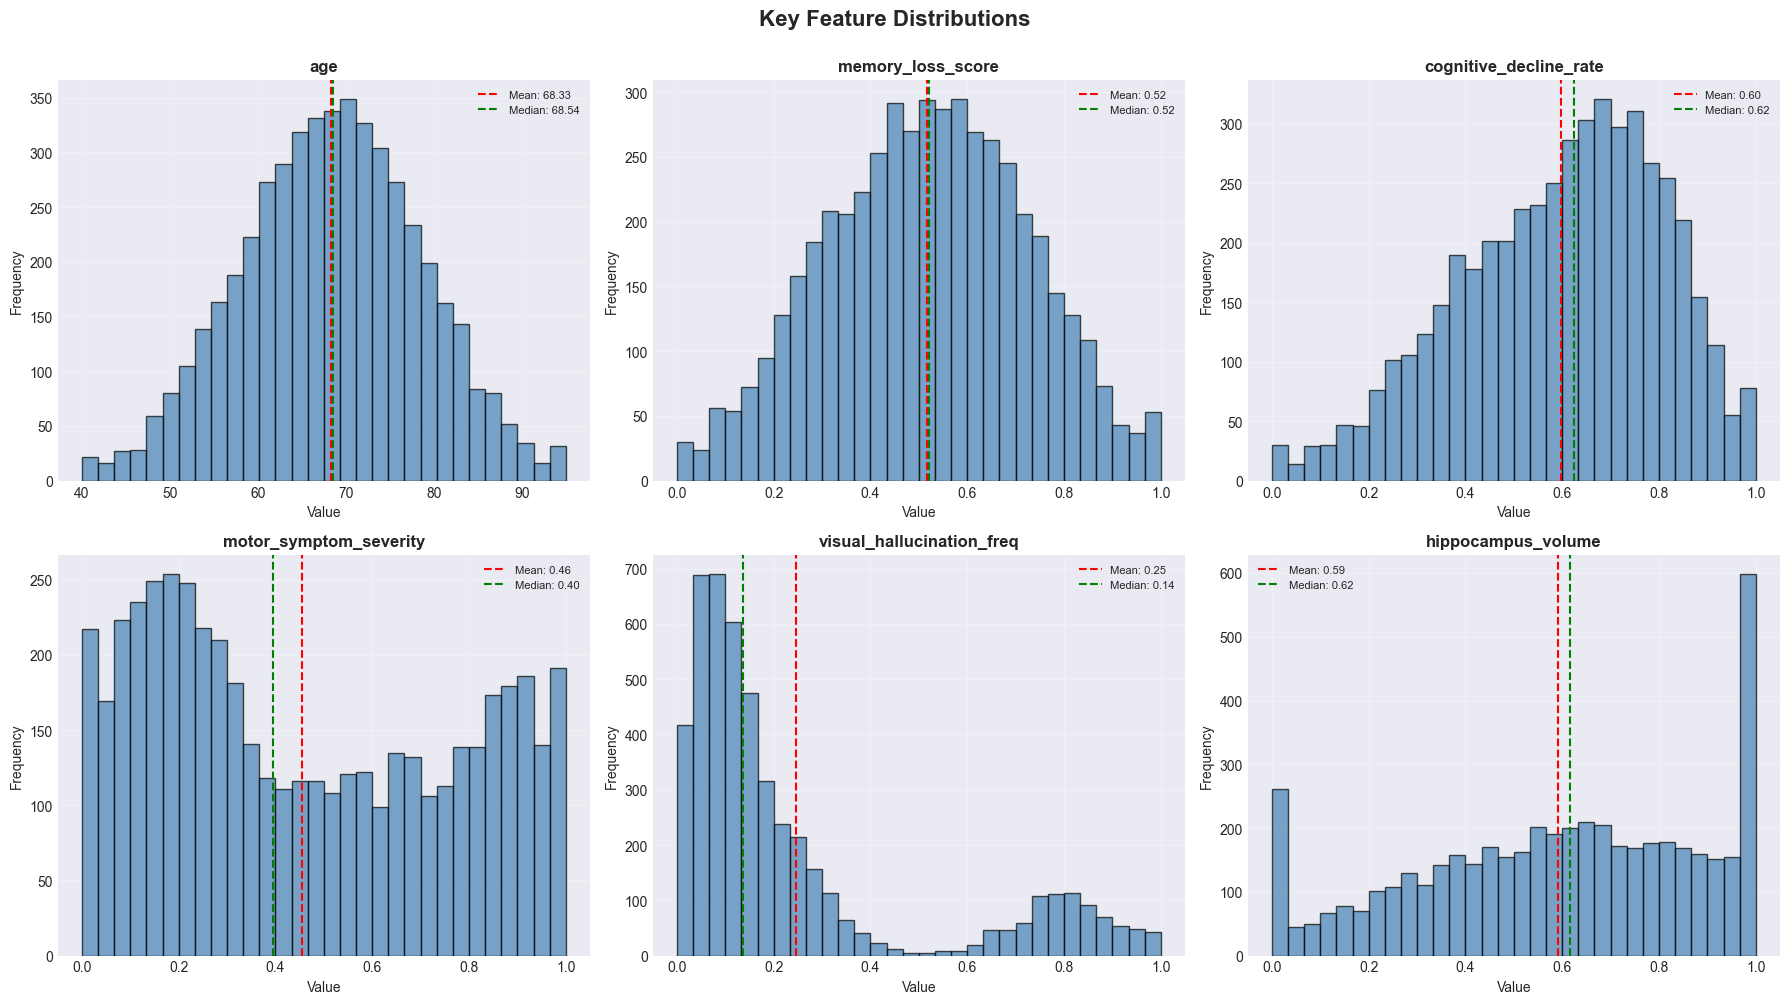

In [8]:
# Analyze key features
key_features = [
    'age', 'memory_loss_score', 'cognitive_decline_rate',
    'motor_symptom_severity', 'visual_hallucination_freq',
    'hippocampus_volume'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(alpha=0.3)
    
    # Add statistics
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

plt.suptitle('Key Feature Distributions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.5 Correlation Analysis

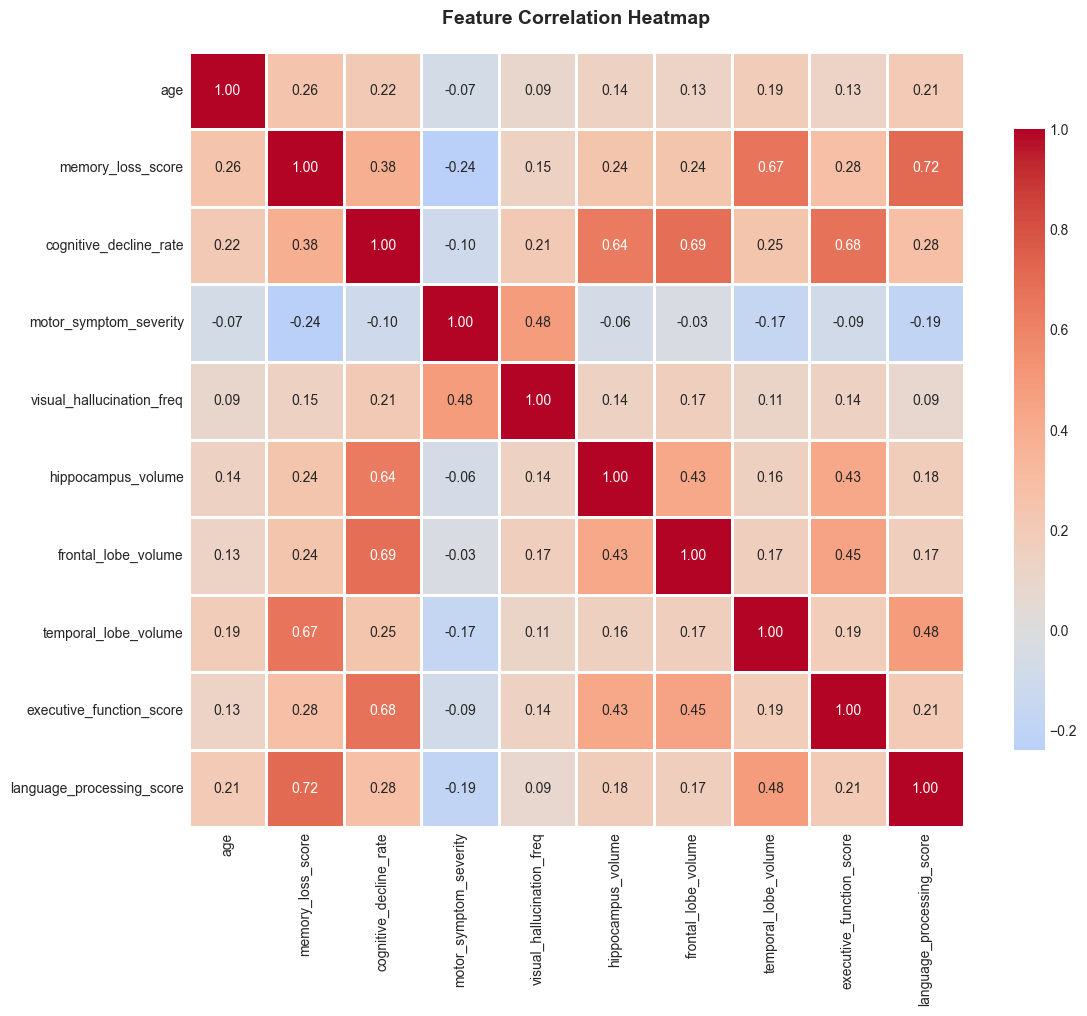


Highly Correlated Feature Pairs (|correlation| > 0.7):
  memory_loss_score <-> language_processing_score: 0.719


In [9]:
# Correlation matrix for key features
correlation_features = key_features + ['frontal_lobe_volume', 'temporal_lobe_volume', 
                                       'executive_function_score', 'language_processing_score']

corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated pairs
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("  No highly correlated pairs found.")

### 3.6 Outlier Detection

In [10]:
# Detect outliers using IQR method
print("\n" + "="*70)
print("OUTLIER DETECTION (IQR Method)")
print("="*70)

outlier_summary = []

for feature in key_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Feature': feature,
        'Outliers': outlier_count,
        'Percentage': f"{outlier_pct:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n", outlier_df.to_string(index=False))


OUTLIER DETECTION (IQR Method)

                   Feature  Outliers Percentage
                      age        16      0.33%
        memory_loss_score         0      0.00%
   cognitive_decline_rate         0      0.00%
   motor_symptom_severity         0      0.00%
visual_hallucination_freq       816     16.69%
       hippocampus_volume         0      0.00%


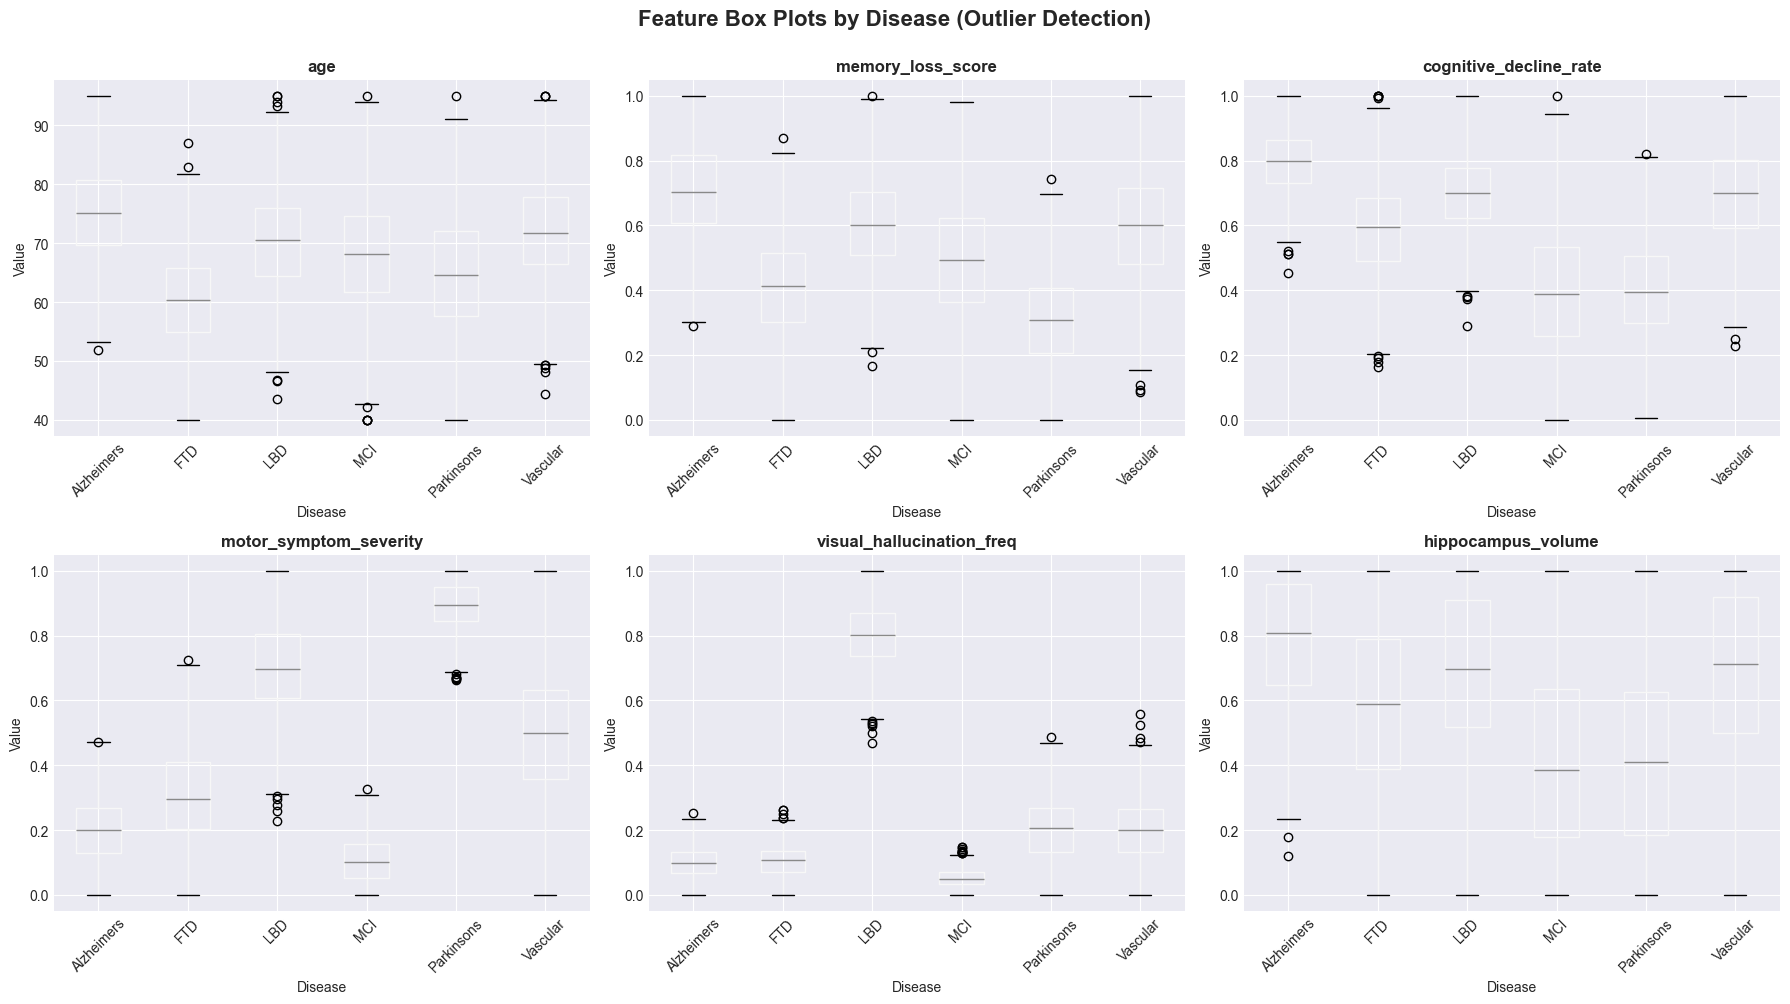

In [11]:
# Box plots for outlier visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    df.boxplot(column=feature, by='disease', ax=axes[idx])
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Disease', fontsize=10)
    axes[idx].set_ylabel('Value', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Box Plots by Disease (Outlier Detection)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing & Cleaning

In [12]:
print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Create a copy for preprocessing
df_processed = df.copy()

# 1. Handle duplicates
duplicates = df_processed.duplicated().sum()
print(f"\n1. Duplicate Rows: {duplicates}")
if duplicates > 0:
    df_processed = df_processed.drop_duplicates()
    print(f"   ✓ Removed {duplicates} duplicate rows")

# 2. Check data types
print(f"\n2. Data Types:")
print(f"   Numeric columns: {len(df_processed.select_dtypes(include=[np.number]).columns)}")
print(f"   Object columns: {len(df_processed.select_dtypes(include=['object']).columns)}")

# 3. Feature range check
print(f"\n3. Feature Range Analysis:")
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
normalized_features = 0
for col in numeric_cols:
    if df_processed[col].min() >= 0 and df_processed[col].max() <= 1:
        normalized_features += 1

print(f"   Features in [0,1] range: {normalized_features}/{len(numeric_cols)}")
print(f"   Features needing scaling: {len(numeric_cols) - normalized_features}/{len(numeric_cols)}")

print(f"\n✓ Preprocessing complete!")
print(f"Final dataset shape: {df_processed.shape}")


DATA PREPROCESSING

1. Duplicate Rows: 0

2. Data Types:
   Numeric columns: 50
   Object columns: 1

3. Feature Range Analysis:
   Features in [0,1] range: 49/50
   Features needing scaling: 1/50

✓ Preprocessing complete!
Final dataset shape: (4889, 51)


## Step 5: Feature Selection & Engineering

### 5.1 Feature Importance Analysis

In [13]:
# Prepare data for feature selection
X = df_processed.drop('disease', axis=1)
y = df_processed['disease']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n" + "="*70)
print("FEATURE SELECTION")
print("="*70)
print(f"\nTotal Features: {X.shape[1]}")
print(f"Target Classes: {le.classes_}")


FEATURE SELECTION

Total Features: 50
Target Classes: ['Alzheimers' 'FTD' 'LBD' 'MCI' 'Parkinsons' 'Vascular']


In [14]:
# Feature importance using Random Forest
print("\nCalculating feature importance...")

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X, y_encoded)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))


Calculating feature importance...

Top 20 Most Important Features:
                  feature  importance
visual_hallucination_freq    0.204949
   motor_symptom_severity    0.184625
   cognitive_decline_rate    0.054164
        memory_loss_score    0.035807
                      age    0.032567
     attention_span_score    0.016038
       cortical_thickness    0.015784
               gait_speed    0.015462
  short_term_memory_score    0.015097
            reaction_time    0.014464
    problem_solving_score    0.014457
     ventricle_size_index    0.014354
   white_matter_integrity    0.014273
       fine_motor_control    0.014205
      brainstem_integrity    0.013282
corpus_callosum_thickness    0.013151
   hand_movement_accuracy    0.012689
 brain_iron_concentration    0.012470
  facial_expression_score    0.012379
    decision_making_score    0.012095


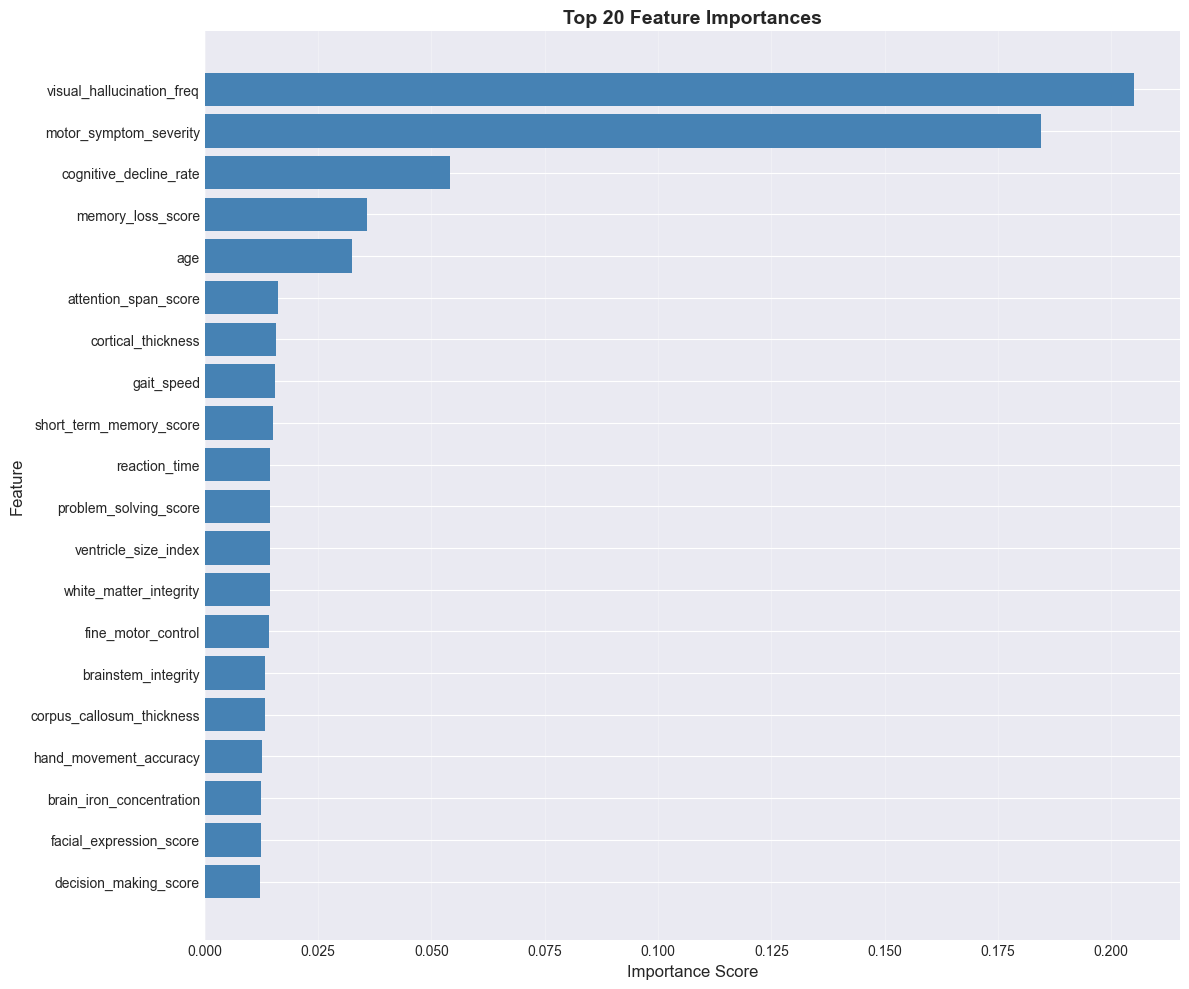

In [15]:
# Visualize feature importance
plt.figure(figsize=(12, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Remove Low-Importance Features

In [16]:
# Keep top features (threshold: importance > 0.01)
importance_threshold = 0.01
selected_features = feature_importance[feature_importance['importance'] > importance_threshold]['feature'].tolist()

print(f"\nFeature Selection Results:")
print(f"  Original features: {len(X.columns)}")
print(f"  Selected features: {len(selected_features)}")
print(f"  Removed features: {len(X.columns) - len(selected_features)}")

# Update X with selected features
X_selected = X[selected_features]

print(f"\n✓ Feature selection complete!")
print(f"Final feature set: {X_selected.shape[1]} features")


Feature Selection Results:
  Original features: 50
  Selected features: 31
  Removed features: 19

✓ Feature selection complete!
Final feature set: 31 features


## Step 6: Split the Dataset

In [17]:
print("\n" + "="*70)
print("DATASET SPLITTING")
print("="*70)

# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nSplit Configuration:")
print(f"  Train size: {len(X_train)} samples ({len(X_train)/len(X_selected)*100:.1f}%)")
print(f"  Test size:  {len(X_test)} samples ({len(X_test)/len(X_selected)*100:.1f}%)")

# Verify stratification
print(f"\nClass Distribution Verification:")
print(f"\nTraining Set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for idx, count in train_dist.items():
    print(f"  {le.classes_[idx]:15s}: {count:4d} ({count/len(y_train)*100:5.2f}%)")

print(f"\nTest Set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for idx, count in test_dist.items():
    print(f"  {le.classes_[idx]:15s}: {count:4d} ({count/len(y_test)*100:5.2f}%)")


DATASET SPLITTING

Split Configuration:
  Train size: 3911 samples (80.0%)
  Test size:  978 samples (20.0%)

Class Distribution Verification:

Training Set:
  Alzheimers     :  641 (16.39%)
  FTD            :  665 (17.00%)
  LBD            :  663 (16.95%)
  MCI            :  625 (15.98%)
  Parkinsons     :  672 (17.18%)
  Vascular       :  645 (16.49%)

Test Set:
  Alzheimers     :  160 (16.36%)
  FTD            :  166 (16.97%)
  LBD            :  166 (16.97%)
  MCI            :  156 (15.95%)
  Parkinsons     :  169 (17.28%)
  Vascular       :  161 (16.46%)


In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Feature scaling complete!")
print(f"  Scaler fitted on training data")
print(f"  Applied to both train and test sets")


✓ Feature scaling complete!
  Scaler fitted on training data
  Applied to both train and test sets


## Step 7: Model Selection

In [19]:
print("\n" + "="*70)
print("MODEL SELECTION")
print("="*70)

# Initialize multiple models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

print(f"\nSelected Models for Training:")
for i, name in enumerate(models.keys(), 1):
    print(f"  {i}. {name}")

print(f"\nTotal Models: {len(models)}")


MODEL SELECTION

Selected Models for Training:
  1. Random Forest
  2. Gradient Boosting
  3. XGBoost
  4. LightGBM

Total Models: 4


## Step 8: Model Training

In [20]:
print("\n" + "="*70)
print("MODEL TRAINING")
print("="*70)

results = {}

for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"✓ Training complete!")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  CV Score:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print(f"\n{'='*70}")
print("ALL MODELS TRAINED SUCCESSFULLY")
print(f"{'='*70}")


MODEL TRAINING

Training: Random Forest
✓ Training complete!
  Accuracy:  0.9080
  Precision: 0.9092
  Recall:    0.9080
  F1-Score:  0.9075
  CV Score:  0.9074 (+/- 0.0097)

Training: Gradient Boosting
✓ Training complete!
  Accuracy:  0.9110
  Precision: 0.9113
  Recall:    0.9110
  F1-Score:  0.9107
  CV Score:  0.9156 (+/- 0.0111)

Training: XGBoost
✓ Training complete!
  Accuracy:  0.9305
  Precision: 0.9307
  Recall:    0.9305
  F1-Score:  0.9301
  CV Score:  0.9212 (+/- 0.0121)

Training: LightGBM
✓ Training complete!
  Accuracy:  0.9294
  Precision: 0.9300
  Recall:    0.9294
  F1-Score:  0.9292
  CV Score:  0.9258 (+/- 0.0087)

ALL MODELS TRAINED SUCCESSFULLY


## Step 9: Model Evaluation

In [21]:
# Model comparison
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1_score'] for m in results],
    'CV Mean': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results]
}).sort_values('Accuracy', ascending=False)

print("\n", comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")


MODEL PERFORMANCE COMPARISON

             Model  Accuracy  Precision   Recall  F1-Score  CV Mean   CV Std
          XGBoost  0.930470   0.930716 0.930470  0.930086 0.921244 0.012141
         LightGBM  0.929448   0.929963 0.929448  0.929250 0.925848 0.008728
Gradient Boosting  0.911043   0.911310 0.911043  0.910722 0.915618 0.011117
    Random Forest  0.907975   0.909196 0.907975  0.907477 0.907436 0.009660

🏆 Best Model: XGBoost
   Accuracy: 0.9305


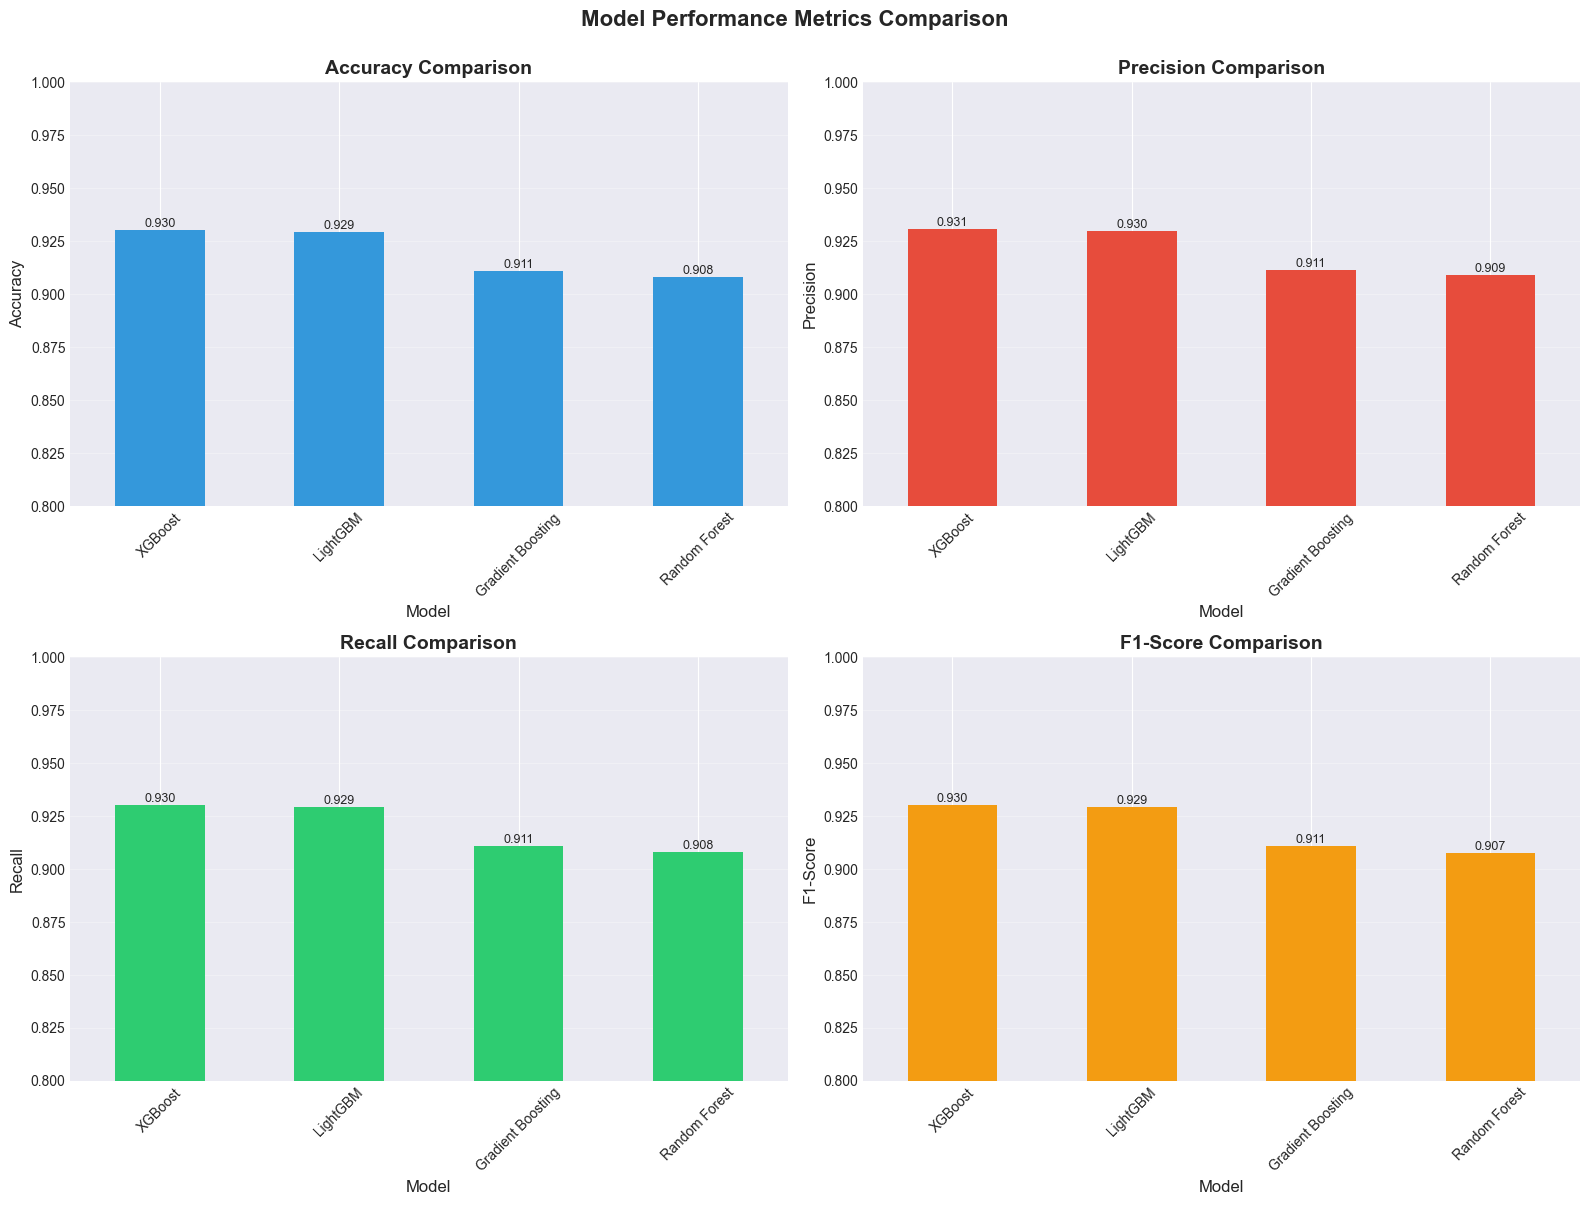

In [22]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, color=color, legend=False)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0.8, 1.0])
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [23]:
# Detailed evaluation of best model
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\n{'='*70}")
print(f"DETAILED EVALUATION: {best_model_name}")
print(f"{'='*70}")
print("\nClassification Report:")
print(classification_report(y_test, best_predictions, target_names=le.classes_))


DETAILED EVALUATION: XGBoost

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.92      0.95      0.94       160
         FTD       0.85      0.87      0.86       166
         LBD       1.00      1.00      1.00       166
         MCI       0.91      0.92      0.91       156
  Parkinsons       0.97      1.00      0.98       169
    Vascular       0.94      0.84      0.89       161

    accuracy                           0.93       978
   macro avg       0.93      0.93      0.93       978
weighted avg       0.93      0.93      0.93       978



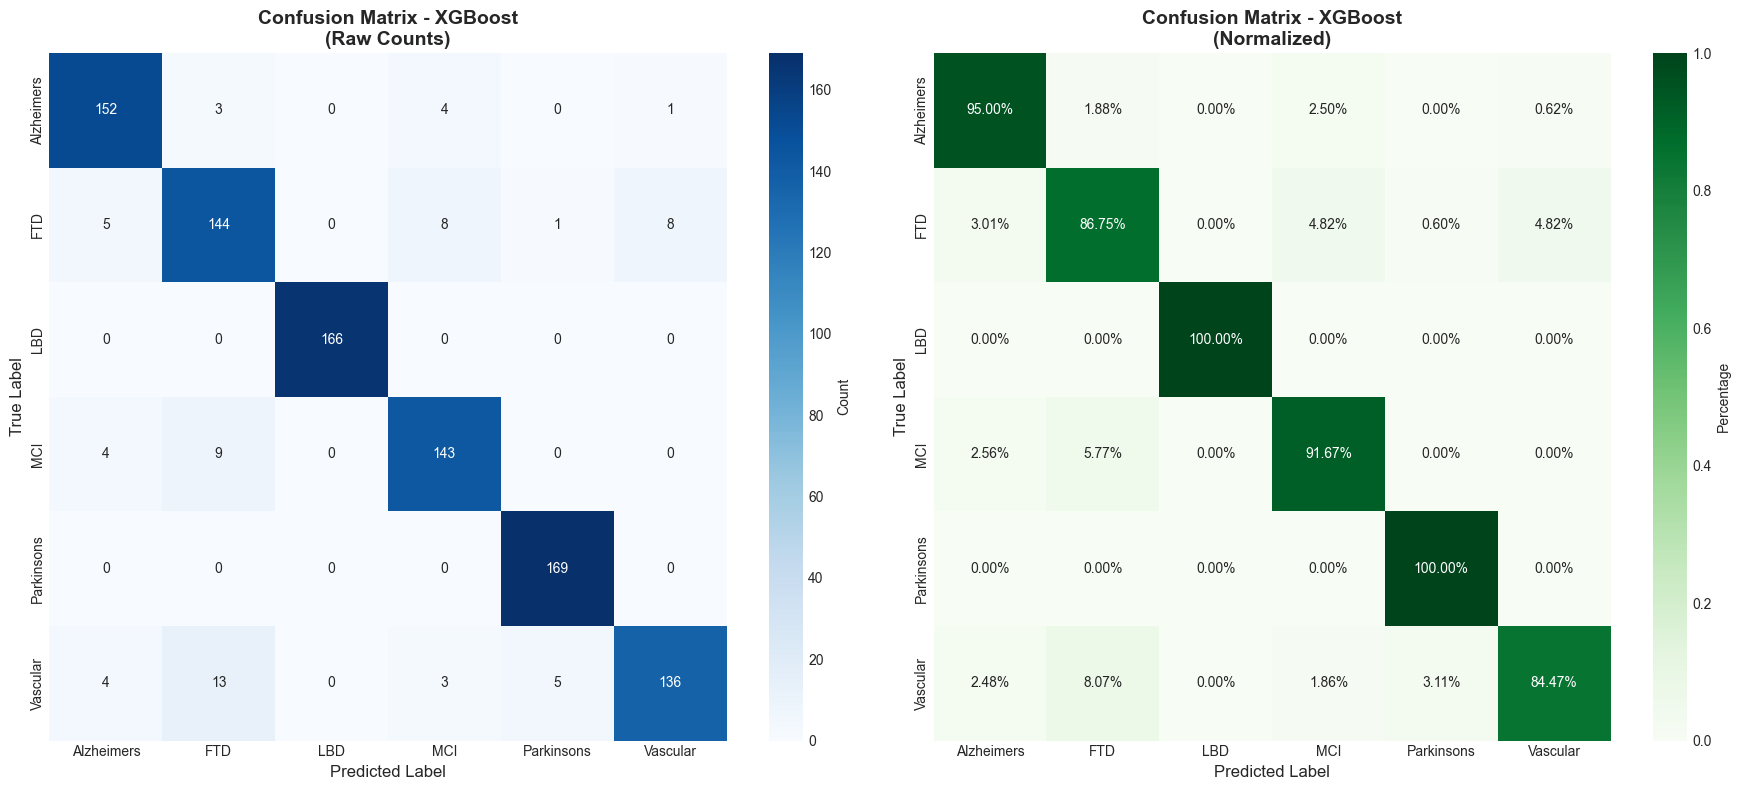

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
axes[0].set_title(f'Confusion Matrix - {best_model_name}\n(Raw Counts)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Normalized
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Percentage'})
axes[1].set_title(f'Confusion Matrix - {best_model_name}\n(Normalized)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

## Step 10: Hyperparameter Tuning

In [25]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid based on best model
if 'LightGBM' in best_model_name:
    param_grid = {
        'n_estimators': [100, 150, 200],
        'max_depth': [5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1]
    }
elif 'XGBoost' in best_model_name:
    param_grid = {
        'n_estimators': [100, 150, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1]
    }
else:
    param_grid = {
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10]
    }

print(f"\nTuning {best_model_name}...")
print(f"Parameter grid: {param_grid}")
print(f"\nThis may take a few minutes...")

# Grid search
grid_search = GridSearchCV(
    best_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Hyperparameter tuning complete!")
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\nPerformance Comparison:")
print(f"  Original Model: {results[best_model_name]['accuracy']:.4f}")
print(f"  Tuned Model:    {accuracy_tuned:.4f}")
print(f"  Improvement:    {(accuracy_tuned - results[best_model_name]['accuracy'])*100:+.2f}%")


HYPERPARAMETER TUNING

Tuning XGBoost...
Parameter grid: {'n_estimators': [100, 150, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1]}

This may take a few minutes...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

✓ Hyperparameter tuning complete!

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV Score: 0.9235

Performance Comparison:
  Original Model: 0.9305
  Tuned Model:    0.9233
  Improvement:    -0.72%


## Step 11: Model Testing & Validation

In [26]:
print("\n" + "="*70)
print("FINAL MODEL VALIDATION")
print("="*70)

# Use tuned model as final model
final_model = tuned_model
y_pred_final = y_pred_tuned

# Final metrics
print("\nFinal Model Performance:")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

# Per-class accuracy
print("\nPer-Class Accuracy:")
cm_final = confusion_matrix(y_test, y_pred_final)
class_accuracy = cm_final.diagonal() / cm_final.sum(axis=1)
for i, disease in enumerate(le.classes_):
    print(f"  {disease:15s}: {class_accuracy[i]*100:6.2f}%")


FINAL MODEL VALIDATION

Final Model Performance:
              precision    recall  f1-score   support

  Alzheimers       0.91      0.94      0.92       160
         FTD       0.85      0.87      0.86       166
         LBD       1.00      1.00      1.00       166
         MCI       0.91      0.89      0.90       156
  Parkinsons       0.97      0.99      0.98       169
    Vascular       0.91      0.85      0.88       161

    accuracy                           0.92       978
   macro avg       0.92      0.92      0.92       978
weighted avg       0.92      0.92      0.92       978


Per-Class Accuracy:
  Alzheimers     :  93.75%
  FTD            :  86.75%
  LBD            : 100.00%
  MCI            :  89.10%
  Parkinsons     :  98.82%
  Vascular       :  85.09%


In [27]:
# Save final model
os.makedirs('models', exist_ok=True)

model_path = 'models/best_model.pkl'
scaler_path = 'models/scaler.pkl'
encoder_path = 'models/label_encoder.pkl'

joblib.dump(final_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(le, encoder_path)

print("\n" + "="*70)
print("MODEL SAVED SUCCESSFULLY")
print("="*70)
print(f"\n✓ Model:   {model_path}")
print(f"✓ Scaler:  {scaler_path}")
print(f"✓ Encoder: {encoder_path}")

print("\n🎉 PIPELINE COMPLETE!")
print("\nModel is ready for deployment in Flask API.")


MODEL SAVED SUCCESSFULLY

✓ Model:   models/best_model.pkl
✓ Scaler:  models/scaler.pkl
✓ Encoder: models/label_encoder.pkl

🎉 PIPELINE COMPLETE!

Model is ready for deployment in Flask API.


## Summary & Conclusions

### Pipeline Summary:
1. ✅ Problem defined and objectives set
2. ✅ Data loaded and explored
3. ✅ Comprehensive EDA performed
4. ✅ Data cleaned and preprocessed
5. ✅ Features selected and engineered
6. ✅ Dataset split with stratification
7. ✅ Multiple models evaluated
8. ✅ Best model identified and trained
9. ✅ Model performance evaluated
10. ✅ Hyperparameters tuned
11. ✅ Final model validated and saved

### Next Steps:
- Deploy model using Flask API (`app.py`)
- Test API endpoints
- Monitor model performance in production
- Collect feedback for model improvements